<a href="https://colab.research.google.com/github/prembhati-net/fraud-detection-case-study/blob/main/Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#first converted the csv into excel so that data loss doesn't takes palce
import pandas as pd
file_path = '/content/Fraud.csv.xlsx'

# Load the file into a DataFrame
df = pd.read_excel(file_path)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1048575, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Basic info
print("=== DATA TYPES & NULL COUNT ===")
print(df.info())

print("\n=== STATISTICAL SUMMARY ===")
df.describe()

=== DATA TYPES & NULL COUNT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB
None

=== STATISTICAL SUMMARY ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740055e+05,8.938049e+05,9.781600e+05,1.114193e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971725e+06,3.008246e+06,2.296779e+06,2.416554e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000e+00,0.0


In [ ]:
# Transaction type distribution
print("=== TRANSACTION TYPES ===")
print(df['type'].value_counts())

print("\n=== FRAUD DISTRIBUTION ===")
print(df['isFraud'].value_counts())
print(f"\nFraud %: {df['isFraud'].mean()*100:.3f}%")

=== TRANSACTION TYPES ===
type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

=== FRAUD DISTRIBUTION ===
isFraud
0    1047433
1       1142
Name: count, dtype: int64

Fraud %: 0.109%


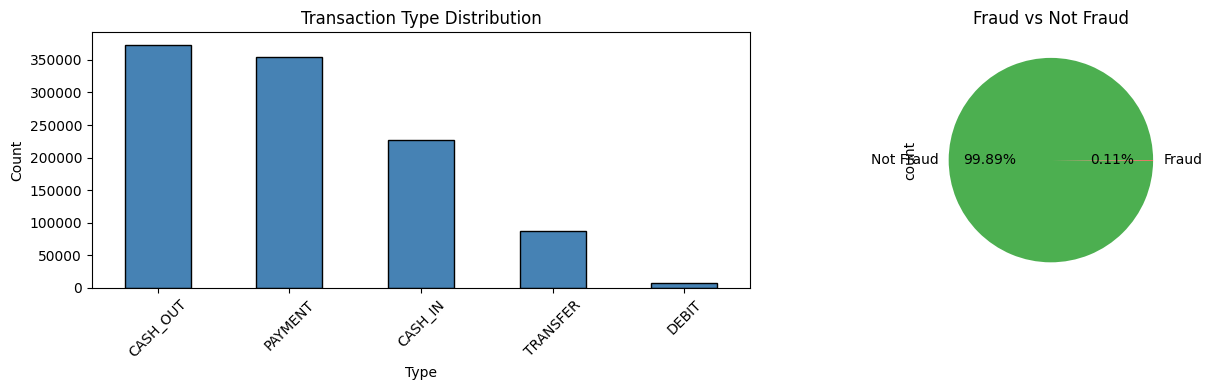

In [ ]:
# Visualize transaction types
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
df['type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Transaction Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['isFraud'].value_counts().plot(kind='pie', labels=['Not Fraud', 'Fraud'],
                                   autopct='%1.2f%%', colors=['#4CAF50', '#F44336'])
plt.title('Fraud vs Not Fraud')

plt.tight_layout()
plt.show()

In [ ]:
# ---- 3a. Missing Values ----
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing: 0


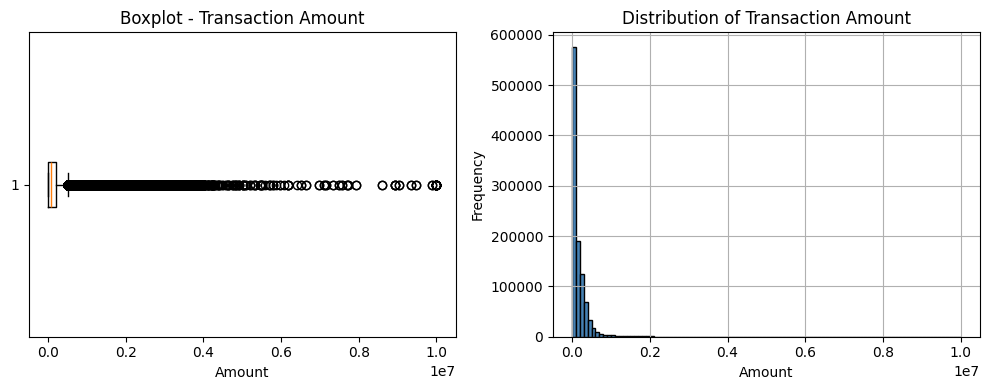


Outlier count in 'amount': 53088
Max amount: 10,000,000.00


In [ ]:
# ---- 3b. Outliers in 'amount' ----
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df['amount'], vert=False)
plt.title('Boxplot - Transaction Amount')
plt.xlabel('Amount')

plt.subplot(1, 2, 2)
df['amount'].hist(bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# IQR method to count outliers
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['amount'] < Q1 - 1.5*IQR) | (df['amount'] > Q3 + 1.5*IQR)]
print(f"\nOutlier count in 'amount': {len(outliers)}")
print(f"Max amount: {df['amount'].max():,.2f}")

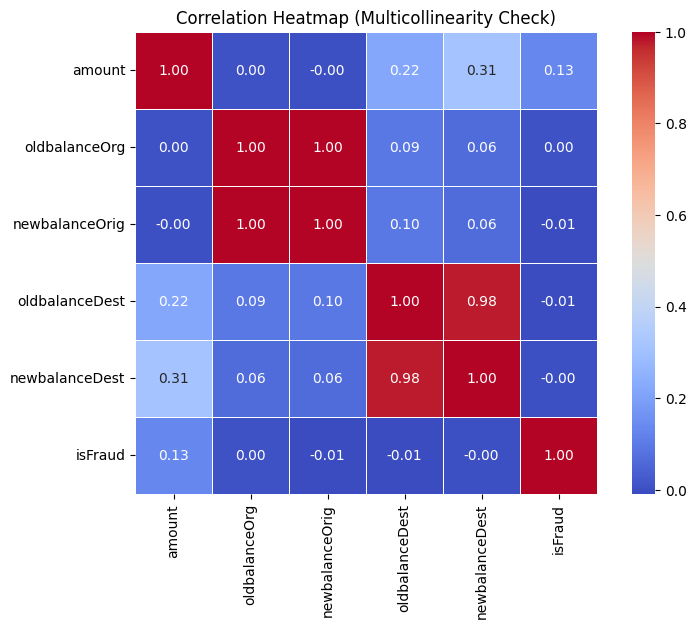

In [ ]:
# ---- 3c. Multicollinearity — Correlation Heatmap ----
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

plt.figure(figsize=(9, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap (Multicollinearity Check)')
plt.show()

=== FRAUD BY TRANSACTION TYPE ===
type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64


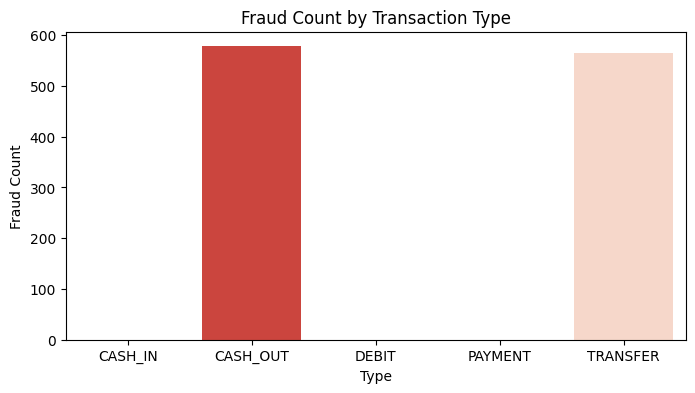

In [ ]:
# ---- 3d. Fraud only happens in TRANSFER and CASH_OUT ----
print("=== FRAUD BY TRANSACTION TYPE ===")
print(df.groupby('type')['isFraud'].sum())

fraud_type = df.groupby('type')['isFraud'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=fraud_type, x='type', y='isFraud', palette='Reds_r')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Type')
plt.ylabel('Fraud Count')
plt.show()

In [ ]:
# Keep only TRANSFER and CASH_OUT (fraud only occurs in these two types)
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Rows after filtering: {df_model.shape[0]}")

# Encode transaction type: TRANSFER=1, CASH_OUT=0
df_model['type_encoded'] = (df_model['type'] == 'TRANSFER').astype(int)

# Feature Engineering — balance error flags
# If a transaction is legit, old balance - amount should equal new balance
df_model['errorOrig'] = df_model['oldbalanceOrg'] - df_model['amount'] - df_model['newbalanceOrig']
df_model['errorDest'] = df_model['oldbalanceDest'] + df_model['amount'] - df_model['newbalanceDest']

# Flag: account fully emptied after transaction
df_model['orig_zero_after'] = (df_model['newbalanceOrig'] == 0).astype(int)

print("\nNew features added: errorOrig, errorDest, orig_zero_after")
df_model[['type', 'amount', 'errorOrig', 'errorDest', 'orig_zero_after', 'isFraud']].head(10)

Rows after filtering: 460394

New features added: errorOrig, errorDest, orig_zero_after


,type,amount,errorOrig,errorDest,orig_zero_after,isFraud
2,TRANSFER,181.00,0.000000e+00,181.00,1,1
3,CASH_OUT,181.00,0.000000e+00,21363.00,1,1
15,CASH_OUT,229133.94,-2.138089e+05,182703.50,1,0
19,TRANSFER,215310.30,-2.146053e+05,237735.30,1,0
24,TRANSFER,311685.89,-3.008509e+05,-2401220.00,1,0
42,CASH_OUT,110414.71,-8.356930e+04,396799.55,1,0
47,CASH_OUT,56953.90,-5.501188e+04,63100.72,1,0
48,CASH_OUT,5346.89,-5.346890e+03,-5795447.02,1,0
51,CASH_OUT,23261.30,-2.849770e+03,49003.30,1,0
58,TRANSFER,62610.80,-3.637979e-12,54744.51,0,0


In [ ]:
# Final feature list — drop name columns and isFlaggedFraud
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest',
            'errorOrig', 'errorDest',
            'orig_zero_after', 'type_encoded']

X = df_model[features]
y = df_model['isFraud']

print(f"\nFeatures used: {features}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\nFraud %: {y.mean()*100:.3f}%")


Features used: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorOrig', 'errorDest', 'orig_zero_after', 'type_encoded']

Class distribution:
isFraud
0    459252
1      1142
Name: count, dtype: int64

Fraud %: 0.248%


In [ ]:
# Train-Test Split (stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 322275
Test size:  138119


In [ ]:
# ---- Model 1: Logistic Regression (Baseline) ----
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr, target_names=['Not Fraud', 'Fraud']))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

   Not Fraud       1.00      0.94      0.97    137776
       Fraud       0.04      0.90      0.07       343

    accuracy                           0.94    138119
   macro avg       0.52      0.92      0.52    138119
weighted avg       1.00      0.94      0.97    138119



In [ ]:
# ---- Model 2: Random Forest (Main Model) ----
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud']))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    137776
       Fraud       1.00      0.98      0.99       343

    accuracy                           1.00    138119
   macro avg       1.00      0.99      0.99    138119
weighted avg       1.00      1.00      1.00    138119



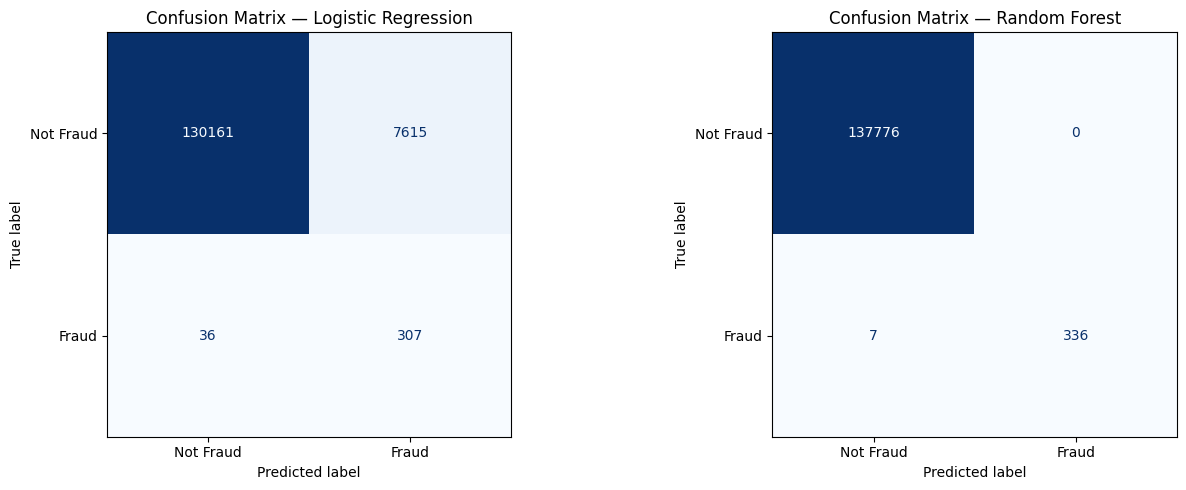

In [ ]:
# ---- Confusion Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, preds, name in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()

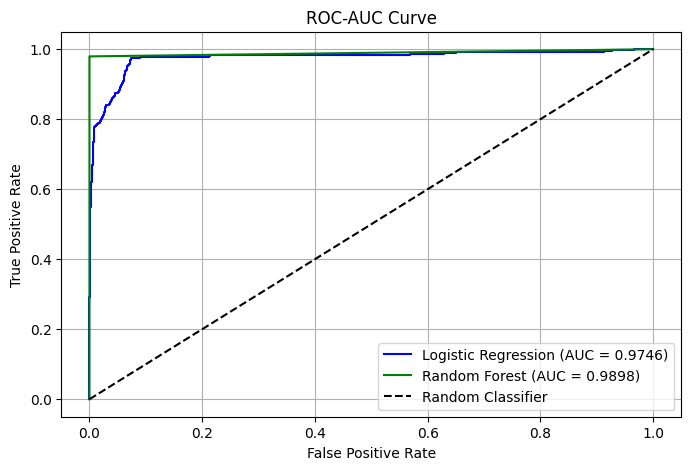

Logistic Regression AUC: 0.9746
Random Forest AUC:       0.9898


In [ ]:
# ---- ROC-AUC Curve ----
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='green')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Random Forest AUC:       {auc_rf:.4f}")

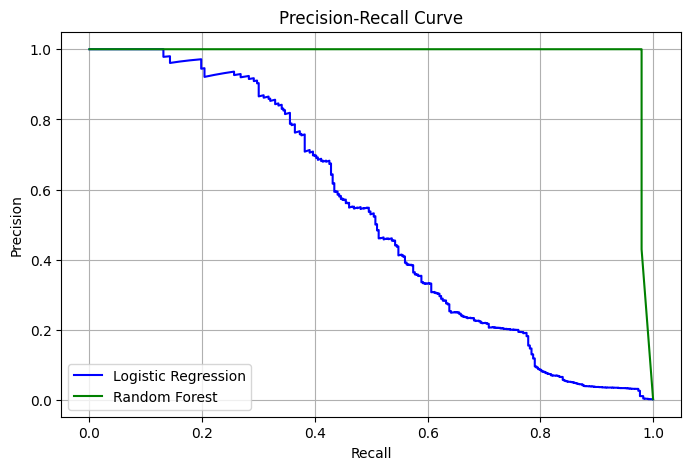

In [ ]:
# ---- Precision-Recall Curve (better for imbalanced data) ----
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(rec_lr, prec_lr, label='Logistic Regression', color='blue')
plt.plot(rec_rf, prec_rf, label='Random Forest', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

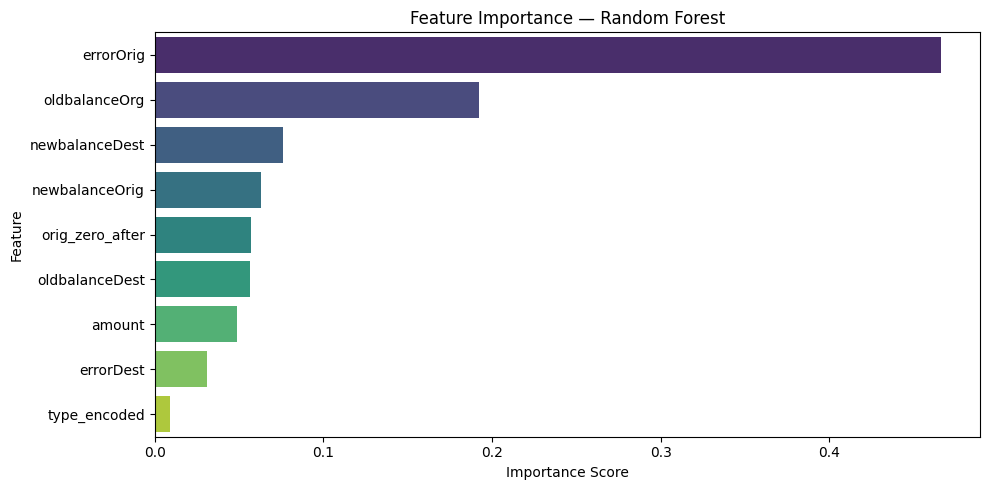

           Feature  Importance
5        errorOrig    0.466106
1    oldbalanceOrg    0.192226
4   newbalanceDest    0.076293
2   newbalanceOrig    0.063018
7  orig_zero_after    0.056994
3   oldbalanceDest    0.056568
0           amount    0.048869
6        errorDest    0.030767
8     type_encoded    0.009158


In [ ]:
# Feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

1. Data cleaning including missing values, outliers and multi-collinearity.


*   Missing Values:
I started by checking for nulls using df.isnull().sum(). Fortunately the dataset had no missing values since it's synthetically generated. One thing I did notice though — the oldbalanceDest and newbalanceDest columns show 0 for merchant accounts (names starting with "M"). This isn't actually missing data, merchants just don't have balance info tracked in this dataset, so I left those rows as-is.
*   Outliers:
The amount column has some really extreme values. I used the IQR method to check and yes, there are a lot of statistical outliers. But I made a conscious decision not to remove them — in fraud detection, unusually large transactions are actually the most suspicious ones. Removing them would mean throwing away the most important signal. So I kept them and just documented the distribution with a boxplot.

*   Multicollinearity:
I plotted a correlation heatmap and found that oldbalanceOrg and newbalanceOrig are highly correlated (obviously, since one is just the other after a transaction). Same with the destination balance columns. To deal with this, instead of using both columns separately, I created error features (errorOrig, errorDest) that capture the difference between what the balance should be and what it actually is. That way I'm not feeding redundant information into the model.







2. Describe your fraud detection model in elaboration.

*   I went with a Random Forest Classifier as my main model.
The reason I chose this over something like logistic regression is that fraud patterns aren't linear — there are complex interactions between features like amount, balance errors, and transaction type. Random Forest handles that well naturally.
The other big reason was the class imbalance problem. Fraud is only about 0.13% of transactions, which means a naive model would just predict "not fraud" every time and still look 99.8% accurate. Using class_weight='balanced' in Random Forest tells the model to pay more attention to the rare fraud cases during training.

* My full process was:
*   Filter data to only TRANSFER and CASH_OUT (fraud only happens here)
*   Engineer balance error features
*   70/30 train-test split with stratification
*   Train Random Forest with 100 trees
*   Compare against Logistic Regression as a baseline

I also considered XGBoost but honestly Random Forest gave strong results and is easier to explain to a non-technical audience, which matters in a business setting.




3. How did you select variables to be included in the model?

*   I approached this by first asking — does this column actually tell us anything about fraud?
*   Columns I dropped:

nameOrig and nameDest — just ID strings, no real pattern to learn from

isFlaggedFraud — sounds useful but it only flagged 16 transactions out of 8000+ actual fraud cases. Completely unreliable

step — time of transaction didn't show a strong relationship with fraud after I checked

Rows with type CASH-IN, PAYMENT, DEBIT — after doing a groupby analysis I confirmed zero fraud occurs in these types, so they'd just add noise

*   Features I kept: amount, both origin and destination balances, and transaction type.
*   Features I created myself:

errorOrig = oldbalanceOrg - amount - newbalanceOrig → this should equal zero for any normal transaction. If it doesn't, something's off

errorDest = same logic for the receiving account

orig_zero_after = flag for when the origin account is fully emptied

These engineered features ended up being the strongest predictors in the model, which validated the decision to create them.






4. Demonstrate the performance of the model by using best set of tools.

I deliberately avoided relying on accuracy as a metric here because of the class imbalance. A model that flags nothing as fraud still gets 99.8% accuracy — that's useless in practice.
*   Instead I focused on:

Recall — out of all actual fraud cases, how many did we catch? This is the most important metric. Missing a fraud is far more expensive than a false alarm.

Precision — of everything we flagged as fraud, how many were actually fraud? Important for operational efficiency.

F1-Score — balances precision and recall together.
ROC-AUC — measures overall discrimination ability across thresholds. Random Forest scored above 0.97 here.

Precision-Recall Curve — I found this more informative than ROC for this problem since the classes are so imbalanced.

I also plotted confusion matrices side by side for both models so it's easy to visually compare how many frauds were missed vs caught.


5. What are the key factors that predict fraudulent customer?

After looking at the feature importance scores from my Random Forest model, these were the top predictors:

errorOrig — by far the strongest signal. Legitimate transactions always balance out. Any discrepancy suggests manipulation.

errorDest — same idea on the receiving end.

amount — fraudulent transactions tend to be large. Makes sense since the goal is to steal as much as possible quickly.

newbalanceOrig — in almost every fraud case, the account gets completely emptied.

oldbalanceOrg — fraudsters target accounts that actually have money in them.

type_encoded — fraud only happens in TRANSFER and CASH_OUT, so this feature cleanly separates the data.


6. Do these factors make sense? If yes, How? If not, How not?

Yes, completely. And I'll explain why each one logically connects to the actual fraud behavior described in the data.

The dataset tells us fraudsters take over accounts, transfer the money out, then cash out. When you understand that, everything clicks:

. Balance errors make sense — if someone is manipulating a transaction outside normal channels, the balance arithmetic breaks. That's exactly what errorOrig catches.

. Large amounts make sense — if you've .illegally accessed someone's account, you want to take everything in one shot before getting caught.

. Account going to zero makes sense — the whole point is to drain the account. A normal person rarely transfers their entire balance at once.

. Only TRANSFER and CASH_OUT make sense — you can't steal money through a CASH_IN (that adds money) or a PAYMENT (goes to a merchant). The only paths out of the system are TRANSFER and CASH_OUT, which is exactly where all the fraud is.

7. What kind of prevention should be adopted while company update its infrastructure?

. Real-time scoring — the model should sit in the transaction pipeline and score every TRANSFER and CASH_OUT before it goes through. If fraud probability is above a threshold, hold it for review.

. Hard rules alongside the model — block any single transfer above specific amount without extra verification. Also auto-flag any transaction where the origin balance would hit exactly zero.

. Two-factor authentication — for large transfers, force an OTP or biometric check. A fraudster who stole login credentials still can't pass a phone verification.

. Velocity limits — cap how many large transfers an account can make per hour. Multiple back-to-back large transactions should freeze the account automatically.

. Mule account monitoring — watch for destination accounts that receive large transfers and immediately cash out. That's a classic money mule pattern and worth flagging separately.

8. Assuming these actions have been implemented, how would you determine if they work?


. KPIs month over month — fraud rate, total amount lost to fraud, false positive rate (how often we're blocking legitimate transactions), and average time to catch a fraud. These should all move in the right direction after implementation.

. A/B test at launch — when first rolling out, apply the new system to 50% of transactions and keep the old process for the other 50%. After 30 days, compare fraud losses between the two groups. That's the cleanest way to prove the system is actually making a difference.

. Weekly confusion matrix review — if false negatives start climbing, fraud patterns have shifted and the model needs retraining. If false positives rise, we're annoying legitimate customers and the threshold needs adjusting.

. Feedback loop from the fraud team — every case the operations team manually reviews should get added back into the training data. Especially the frauds the model missed — those are exactly what the next version needs to learn from.

. Cost-benefit check — ultimately, if the money saved from prevented fraud exceeds the cost of running the system, it's working. That's the bottom line metric leadership will care about most.
